In [1]:
# Install libraries
!pip install scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded!')

All libraries loaded!


In [3]:
# Load the dataset
df = pd.read_csv('combined_ai_tweet_detection_dataset.csv')

print(f'Dataset loaded!')
print(f'Total rows: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'\nFirst 5 rows:')
df.head()

Dataset loaded!
Total rows: 35443
Columns: ['text', 'label', 'source_dataset', 'original_label', 'generator_type', 'split']

Label distribution:
label
1    19796
0    15647
Name: count, dtype: int64

First 5 rows:


,text,label,source_dataset,original_label,generator_type,split
0,YEA now that note GOOD,1,TweepFake,bot,others,train
1,Listen to This Charming Man by The Smiths http...,0,TweepFake,human,human,train
2,wish i can i would be seeing other hoes on the...,1,TweepFake,bot,others,train
3,The decade in the significantly easier schedul...,1,TweepFake,bot,others,train
4,"""Theim class=\""alignnone size-full wp-image-60...",1,TweepFake,bot,rnn,train


In [4]:
# Train/test split
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f'Training set: {len(X_train)} tweets')
print(f'Testing set: {len(X_test)} tweets')
print(f'\nTraining label distribution:')
print(y_train.value_counts())
print(f'\nTesting label distribution:')
print(y_test.value_counts())

Training set: 28354 tweets
Testing set: 7089 tweets

Training label distribution:
label
1    15837
0    12517
Name: count, dtype: int64

Testing label distribution:
label
1    3959
0    3130
Name: count, dtype: int64


In [6]:
from sklearn.pipeline import Pipeline

# Build and train Logistic Regression model
lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        max_features=50000
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)


# Evaluate
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

print('\n=== LOGISTIC REGRESSION RESULTS ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred, target_names=["Human", "AI Generated"]))


=== LOGISTIC REGRESSION RESULTS ===
Accuracy:  0.8235
Precision: 0.8330
Recall:    0.8555
F1-Score:  0.8441
AUC-ROC:   0.9189

Detailed Report:
              precision    recall  f1-score   support

       Human       0.81      0.78      0.80      3130
AI Generated       0.83      0.86      0.84      3959

    accuracy                           0.82      7089
   macro avg       0.82      0.82      0.82      7089
weighted avg       0.82      0.82      0.82      7089



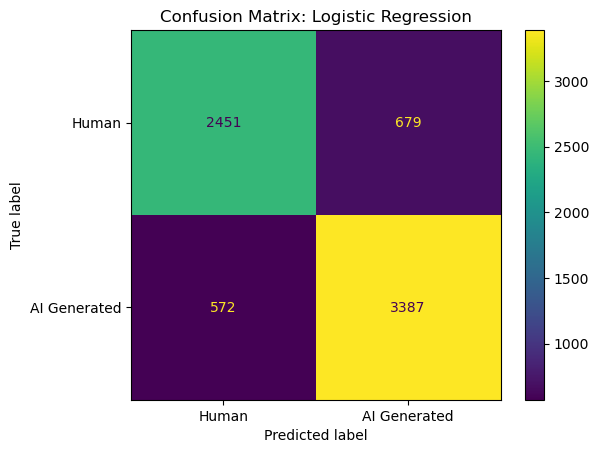

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI Generated"]
)
disp.plot()
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

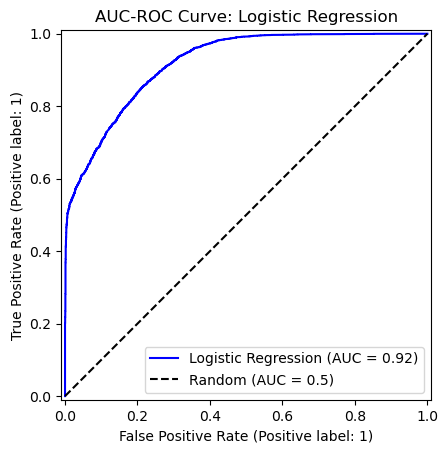

In [ ]:
# theb AUC-ROC curve ,shows how well the model distinguishes between human and AI tweets
# The closer the curve is to the top left corner the better the model
# AUC = 1.0 is perfect, AUC = 0.5 means the model is just guessing randomly
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression",
    color="blue"
)
plt.title("AUC-ROC Curve: Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
plt.legend()
plt.show()

In [9]:
# Extract the TF-IDF vectorizer and classifier from the pipeline
tfidf = lr_model.named_steps["tfidf"]
classifier = lr_model.named_steps["classifier"]

# Get feature names and their coefficients
# Positive coefficients = words that push toward AI Generated
# Negative coefficients = words that push toward Human
feature_names = tfidf.get_feature_names_out()
coefficients = classifier.coef_[0]

# Top 15 words most associated with AI generated tweets
top_ai = pd.DataFrame({
    "word": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False).head(15)

# Top 15 words most associated with human written tweets
top_human = pd.DataFrame({
    "word": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=True).head(15)

print("Top words pushing toward AI Generated:")
print(top_ai)
print("\nTop words pushing toward Human:")
print(top_human)

Top words pushing toward AI Generated:
                     word  coefficient
4444               county     8.638407
16205     realdonaldtrump     4.310953
6431            elections     4.027934
20800                vote     3.955559
21314              voting     3.836545
16427        registration     3.794100
10528                java     3.784918
4223           corruption     3.704438
12331            machines     3.674570
21061  voter registration     3.656309
6248             election     3.586285
7303                 file     3.429353
7319                files     3.342723
10175             install     3.319240
6396    electionintegrity     3.317542

Top words pushing toward Human:
                 word  coefficient
9503            https   -23.643595
7675            fraud    -6.993926
21050     voter fraud    -6.849171
51           0001f44d    -4.031172
10953    kafirlaugher    -3.724247
13535      nabrathhhh    -3.652028
8624   griffin_lilly2    -3.590100
2376        bignish20   

In [10]:

# Unigram vs Bigram Comparison


# Unigram model, looks at single words only
unigram_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 1),
        max_features=50000
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

unigram_model.fit(X_train, y_train)
y_pred_uni = unigram_model.predict(X_test)

print('=== UNIGRAM MODEL (single words only) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_uni):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_uni):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_uni):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_uni):.4f}')

print('\n=== BIGRAM MODEL (single words + pairs) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred):.4f}')

print('\nConclusion: Bigram model performs better because word pairs')
print('give more context than single words alone.')

=== UNIGRAM MODEL (single words only) ===
Accuracy:  0.8228
Precision: 0.8313
Recall:    0.8565
F1-Score:  0.8437

=== BIGRAM MODEL (single words + pairs) ===
Accuracy:  0.8235
Precision: 0.8330
Recall:    0.8555
F1-Score:  0.8441

Conclusion: Bigram model performs better because word pairs
give more context than single words alone.
